# Análisis del dataset Diabetes mediante PCA y cuadrados mínimos

En este trabajo se utilizará el dataset **Diabetes**, disponible en `diabetes_dataset.csv`. La última columna del dataset, target será la variable target que se debe predecir en función de las otras columnas.  Este dataset contiene un conjunto de $n$ muestras correspondientes a pacientes, donde cada muestra contiene $p$ variables clínicas estandarizadas.

Cada muestra puede escribirse como:

$$
\{\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_i, \dots, \mathbf{x}_n\}
$$

donde:

$$
\mathbf{x}_i \in \mathbb{R}^{p}
$$

Por lo tanto, el dataset puede representarse mediante una matriz:

$$
X \in \mathbb{R}^{n \times p}
$$

En el caso del dataset Diabetes, cada fila representa una muestra y cada columna representa una variable clínica. Además, el dataset viene acompañado de una variable respuesta $\mathbf{y}$, que mide una progresión cuantitativa de la enfermedad para cada paciente.

Aunque la dimensión del dataset no es extremadamente alta, sigue siendo útil estudiar si las variables originales pueden representarse en un espacio de menor dimensión sin perder demasiada información relevante. Para esto se utilizará **PCA**, implementado a partir de la **Descomposición en Valores Singulares**.

También se analizará cómo cambia la similaridad entre muestras al modificar la dimensión reducida $d$, y cómo afecta esta reducción de dimensionalidad a un modelo lineal ajustado mediante cuadrados mínimos.

La similaridad entre dos muestras $\mathbf{x}_i$ y $\mathbf{x}_j$ se puede medir utilizando una función no lineal de su distancia euclidiana:

$$
K\left(\mathbf{x}_i, \mathbf{x}_j\right)
=
\exp \left(
-\frac{
\left\|\mathbf{x}_i-\mathbf{x}_j\right\|_2^2
}{
2\sigma^2
}
\right)
$$

donde $\sigma$ es un parámetro que controla qué tan rápido decrece la similaridad con la distancia.

Esta función asigna valores cercanos a $1$ a pares de muestras muy similares, y valores cercanos a $0$ a pares de muestras muy diferentes.

## Consignas

### 1. Estandarización, SVD y reducción de dimensión

Cargar el dataset Diabetes y construir la matriz de datos $X$ y el vector respuesta $\mathbf{y}$.

Estandarizar la matriz $X$, es decir, transformar cada variable para que tenga media cero y desviación estándar uno.

Luego, realizar una descomposición en valores singulares de la matriz estandarizada:

$$
X = U \Sigma V^T
$$

A partir de esta descomposición, construir representaciones de baja dimensión proyectando las muestras sobre los primeros $d$ componentes principales.

Es decir, para cada muestra:

$$
\mathbf{z}_i = V_d^T \mathbf{x}_i
$$

donde $V_d$ contiene las primeras $d$ direcciones principales.

Realizar este procedimiento para:

$$
d = 2,\ 6,\ 10,\ p
$$

Analizar:

- ¿Qué representan los vectores $\mathbf{z}_i$?
- ¿Qué información contienen los primeros componentes principales?
- ¿Por qué es conveniente estandarizar $X$ antes de aplicar PCA?
- ¿Qué relación existe entre los valores singulares y la cantidad de información explicada por cada componente?

---

### 2. Análisis de similaridad entre muestras

Analizar la similaridad par-a-par entre muestras en el espacio original $X$ y en los espacios reducidos obtenidos mediante PCA.

Para esto, construir la matriz de similaridad:

$$
K\left(\mathbf{x}_i, \mathbf{x}_j\right)
=
\exp \left(
-\frac{
\left\|\mathbf{x}_i-\mathbf{x}_j\right\|_2^2
}{
2\sigma^2
}
\right)
$$

Primero, calcular la matriz de similaridad usando las muestras en el espacio original estandarizado $X$.

Luego, calcular matrices de similaridad equivalentes usando las representaciones reducidas:

$$
Z_2,\ Z_6,\ Z_{10},\ Z_p
$$

Comparar visualmente las matrices de similaridad obtenidas.

Analizar:

- ¿Qué diferencias se observan entre la matriz de similaridad en el espacio original y las matrices obtenidas con dimensión reducida?
- ¿Qué sucede cuando se usa una dimensión muy baja, por ejemplo $d=2$?
- ¿A partir de qué valor de $d$ la matriz de similaridad se parece razonablemente a la obtenida en el espacio original?
- ¿Cómo se relaciona esto con los valores singulares de $X$?
- ¿La reducción de dimensión preserva las relaciones de cercanía entre muestras?

---

### 3. Modelo lineal en el espacio original

El dataset viene acompañado de una variable dependiente o respuesta $\mathbf{y}$, asociada a cada muestra.

Esta variable puede representarse como:

$$
\mathbf{y} \in \mathbb{R}^{n \times 1}
$$

Antes de ajustar el modelo, centrar el vector respuesta restando su media:

$$
\mathbf{y}_{\text{centrado}} = \mathbf{y} - \bar{y}
$$

Luego, resolver el problema de cuadrados mínimos en el espacio original:

$$
\min_{\hat{\beta}_x}
\left\|X \hat{\beta}_x - \mathbf{y}_{\text{centrado}}\right\|_2
$$

donde $\hat{\beta}_x$ es el vector de coeficientes del modelo lineal.

La predicción del modelo está dada por:

$$
\hat{\mathbf{y}} = X \hat{\beta}_x
$$

Analizar:

- ¿Cuál es el error de predicción del modelo?
- ¿Qué variables tienen mayor peso en el vector $\hat{\beta}_x$?
- ¿Qué interpretación puede darse a los signos y magnitudes de los coeficientes?
- ¿El modelo lineal logra explicar una parte significativa de la variabilidad de $\mathbf{y}$?



---

### 4. Modelos lineales en espacios reducidos

Usando las representaciones aprendidas mediante PCA, resolver problemas de cuadrados mínimos en espacios reducidos.

Para cada dimensión $d$, resolver:

$$
\min_{\hat{\beta}_z}
\left\|Z_d \hat{\beta}_z - \mathbf{y}_{\text{centrado}}\right\|_2
$$

donde $Z_d$ es la matriz de datos proyectada sobre los primeros $d$ componentes principales.

Realizar este ajuste para distintos valores de $d$, por ejemplo:

$$
d = 1,\ 2,\ 3,\dots,p
$$

Para cada valor de $d$, calcular alguna medida de error, por ejemplo:

$$
E(d) =
\left\|Z_d \hat{\beta}_z - \mathbf{y}_{\text{centrado}}\right\|_2
$$

o también el error cuadrático medio:

$$
RMSE(d)
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
\left(
\hat{y}_i - y_i
\right)^2
}
$$

Graficar el error de predicción en función de la dimensión $d$.

Analizar:

- ¿Cómo cambia el error al aumentar $d$?
- ¿Usar pocos componentes principales mejora o empeora la predicción?
- ¿Existe un valor de $d$ a partir del cual agregar más componentes produce poca mejora?
- ¿Cómo se relaciona este comportamiento con los valores singulares de $X$?
- ¿El modelo en el espacio reducido alcanza un error comparable al modelo en el espacio original?
- ¿Qué dimensión $d$ elegirían si quisieran equilibrar simplicidad del modelo y capacidad predictiva?
- Si utiliza más dimensiones puede correr el riesgo de sobrecomplejizar el modelo al agregar variables que hagan que el residuo disminuzca. ¿Qué estrategia se le ocurre para poder mitigar ese efecto y ser más imparcial a la hora de testear el modelo con distintas dimensiones?

---

### 5. Visualización del error por muestra

Para el mejor modelo obtenido, calcular el residuo absoluto de cada muestra:

$$
r_i =
\left|
\hat{y}_i - y_i
\right|
$$

Visualizar estos residuos, por ejemplo:

- como un gráfico de residuos ordenados,
- como un histograma,
- o coloreando las muestras en el plano de los dos primeros componentes principales.

Analizar:

- ¿Hay muestras que son predichas mucho mejor que otras?
- ¿Hay muestras con errores particularmente grandes?
- ¿Dónde se ubican las muestras con mayor error en la proyección PCA con $d=2$?
- ¿Qué puede indicar esto sobre las limitaciones del modelo lineal?
```



3)

In [24]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler


df = pd.read_csv("diabetes.csv")

X_df = df.drop(columns=["target"])
y = df["target"].to_numpy()

X = StandardScaler().fit_transform(X_df)
y_centrado = np.subtract(y, np.mean(y))


def cuadrados_minimos_svd(X, y):
    U, s, Vt = np.linalg.svd(X, full_matrices=False)

    tolerancia = np.finfo(float).eps * max(X.shape) * s[0]

    s_inversa = np.zeros_like(s)

    for i in range(len(s)):
        if s[i] > tolerancia:
            s_inversa[i] = np.divide(1, s[i])

    return Vt.T @ (s_inversa * (U.T @ y))


beta = cuadrados_minimos_svd(X, y_centrado)

y_pred = X @ beta
residuos = np.subtract(y_centrado, y_pred)

error = np.sqrt(np.sum(residuos ** 2))
rmse = np.sqrt(np.mean(residuos ** 2))

r2 = np.subtract(
    1,
    np.divide(
        np.sum(residuos ** 2),
        np.sum(y_centrado ** 2)
    )
)

coeficientes = pd.DataFrame({
    "variable": X_df.columns,
    "coeficiente": beta,
    "peso": np.abs(beta)
})

print("Error:", error)
print("RMSE:", rmse)
print("R2:", r2)
print()
print(coeficientes)

Error: 1124.2712242307653
RMSE: 53.476128764026576
R2: 0.5177484222203498

  variable  coeficiente       peso
0      age    -0.476121   0.476121
1      sex   -11.406867  11.406867
2      bmi    24.726549  24.726549
3       bp    15.429404  15.429404
4       s1   -37.679953  37.679953
5       s2    22.676163  22.676163
6       s3     4.806138   4.806138
7       s4     8.422039   8.422039
8       s5    35.734446  35.734446
9       s6     3.216674   3.216674


-El error total del modelo es aproximadamente 1124.27 y el RMSE es aproximadamente 53.48. Esto indica que las predicciones se alejan de los valores reales cerca de 53 unidades en promedio.

-Las variables con mayor peso son s1, s5, bmi y s2, ya que tienen los coeficientes con mayor valor absoluto.

-Un coeficiente positivo indica que al aumentar la variable tambien aumenta la prediccion. Un coeficiente negativo indica que al aumentar la variable disminuye la prediccion. Cuanto mayor es el valor absoluto del coeficiente, mayor es su influencia en el modelo.

-El valor de R2 es aproximadamente 0.518. Esto significa que el modelo explica cerca del 51.8 por ciento de la variabilidad de la variable target. Por lo tanto, el modelo explica una parte importante de los datos, aunque todavia existe una parte considerable que no puede explicar.

4)

,dimension,RMSE
0,1,64.038864
1,2,62.276890
2,3,61.020884
3,4,54.434542
4,5,54.430712
5,6,54.022639
6,7,53.745608
7,8,53.691873
8,9,53.685018
9,10,53.476129


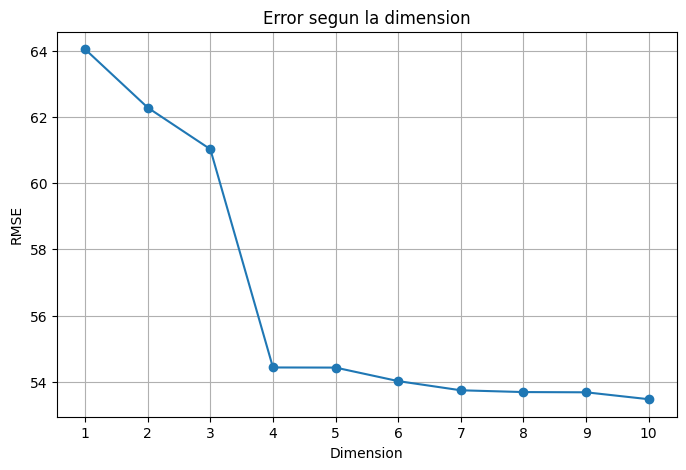

In [25]:
import matplotlib.pyplot as plt

_, valores_singulares, Vt = np.linalg.svd(X, full_matrices=False)

dimensiones = range(1, X.shape[1] + 1)
errores = []

for d in dimensiones:
    Z_d = X @ Vt[:d].T

    beta_d = cuadrados_minimos_svd(Z_d, y_centrado)

    y_pred_d = Z_d @ beta_d

    rmse_d = np.sqrt(
        np.mean((y_centrado - y_pred_d) ** 2)
    )

    errores.append(rmse_d)


resultados = pd.DataFrame({
    "dimension": dimensiones,
    "RMSE": errores
})

display(resultados)


plt.figure(figsize=(8, 5))

plt.plot(
    resultados["dimension"],
    resultados["RMSE"],
    marker="o"
)

plt.xlabel("Dimension")
plt.ylabel("RMSE")
plt.title("Error segun la dimension")
plt.xticks(list(dimensiones))
plt.grid()

plt.show()

-El error disminuye al aumentar la dimension. Esto ocurre porque el modelo dispone de mas informacion para realizar las predicciones.

-Con una o dos componentes el error es mayor, por lo que usar una dimension demasiado baja empeora la prediccion.

-La mayor mejora se observa al pasar de tres a cuatro componentes. A partir de seis componentes, agregar nuevas dimensiones produce una mejora pequena.

-Este comportamiento se relaciona con los valores singulares. Las primeras componentes contienen la mayor parte de la informacion de los datos. Las ultimas componentes aportan menos informacion y por eso producen cambios menores en el error.

-Con diez componentes se obtiene el mismo resultado que en el espacio original, ya que se estan utilizando todas las dimensiones disponibles.

-Elegiria una dimension igual a seis. Esta dimension produce un error cercano al modelo completo, pero utiliza menos variables.

-Para comparar los modelos de forma mas justa se puede dividir el dataset en datos de entrenamiento y datos de prueba. Tambien se puede usar validacion cruzada. El PCA y el modelo deben calcularse solamente con los datos de entrenamiento y luego evaluarse con datos que no fueron usados durante el ajuste.


5)

Mejor dimension: 10
Error promedio: 43.27745202531505
Mayor error: 155.82676612155183
Muestra con mayor error: 56


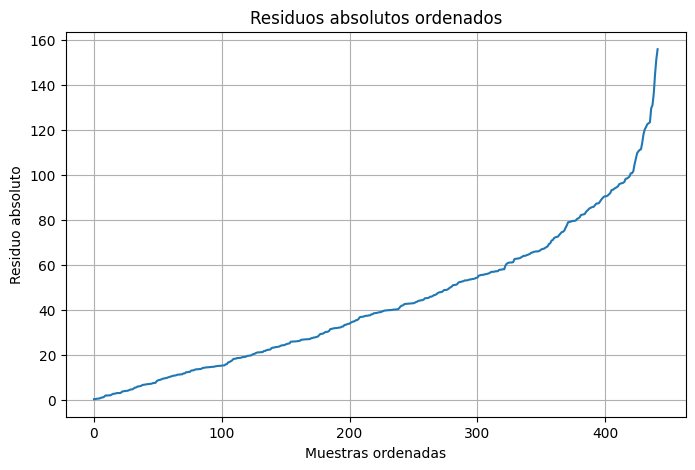

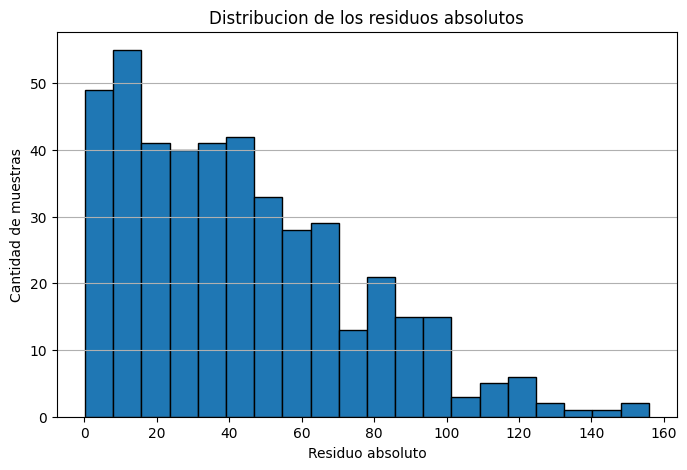

In [26]:
mejor_indice = np.argmin(errores)
mejor_dimension = list(dimensiones)[mejor_indice]

Z_mejor = X @ Vt[:mejor_dimension].T

beta_mejor = cuadrados_minimos_svd(
    Z_mejor,
    y_centrado
)

y_pred = np.add(Z_mejor @ beta_mejor, np.mean(y))

residuos_absolutos = np.abs(np.subtract(y, y_pred))

indice_mayor_error = np.argmax(residuos_absolutos)

print("Mejor dimension:", mejor_dimension)
print("Error promedio:", np.mean(residuos_absolutos))
print("Mayor error:", residuos_absolutos[indice_mayor_error])
print("Muestra con mayor error:", indice_mayor_error)


residuos_ordenados = np.sort(residuos_absolutos)

plt.figure(figsize=(8, 5))

plt.plot(residuos_ordenados)

plt.xlabel("Muestras ordenadas")
plt.ylabel("Residuo absoluto")
plt.title("Residuos absolutos ordenados")
plt.grid()

plt.show()

plt.figure(figsize=(8, 5))

plt.hist(
    residuos_absolutos,
    bins=20,
    edgecolor="black"
)

plt.xlabel("Residuo absoluto")
plt.ylabel("Cantidad de muestras")
plt.title("Distribucion de los residuos absolutos")
plt.grid(axis="y")

plt.show()

-Algunas muestras tienen residuos cercanos a cero, por lo que fueron predichas con mucha precision. Sin embargo, otras presentan errores mayores. La mayor parte de las muestras tiene residuos entre 0 y 70 unidades.

-En ambos graficos se observa un grupo pequeño de muestras con errores mayores a 100 unidades. El mayor residuo es cercano a 156 unidades, por lo que el modelo tiene dificultades para predecir correctamente algunos casos particulares.

**Donde se ubican las muestras con mayor error en la proyeccion PCA con d igual a 2**
??

-Los resultados indican que el modelo funciona de manera razonable para muchas muestras, pero no logra representar correctamente todos los casos. Esto puede ocurrir porque existen relaciones no lineales, casos diferentes al resto o informacion importante que no esta incluida en las variables del dataset.
